In [1]:
!pip install requests beautifulsoup4 pandas

In [2]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [3]:
## Scrape Article Links and Metadata

def scrape_et_rbi_policy(num_pages=3):
    base_url = "https://economictimes.indiatimes.com/markets/rbi-policy"
    articles = []
    for pg in range(1, num_pages + 1):
        url = f"{base_url}?curpg={pg}"
        res = requests.get(url)
        soup = BeautifulSoup(res.text, "html.parser")
        for entry in soup.find_all("div", class_="eachStory"):
            h3 = entry.find("h3")
            if h3 and h3.find("a"):
                link = "https://economictimes.indiatimes.com" + h3.find("a")["href"]
                title = h3.text.strip()
                summary = entry.find("p").text.strip() if entry.find("p") else ""
                articles.append({"title": title, "url": link, "summary": summary})
        time.sleep(1)  # Polite
    return pd.DataFrame(articles)


In [4]:
df = scrape_et_rbi_policy(num_pages=2)
print(df.head())

                                               title  \
0                                 RBI Policy Preview   
1  RBI policy and GST boost fuel interest in cons...   
2  RBI MPC meeting: Top highlights on repo rate, ...   
3  RBI Policy Meeting 2025: Key highlights and go...   
4  India benchmark bonds fall on supply reshuffle...   

                                                 url  \
0  https://economictimes.indiatimes.comhttps://ec...   
1  https://economictimes.indiatimes.comhttps://ec...   
2  https://economictimes.indiatimes.comhttps://ec...   
3  https://economictimes.indiatimes.comhttps://ec...   
4  https://economictimes.indiatimes.comhttps://ec...   

                                             summary  
0                                                     
1  Consumption and financial services stocks are ...  
2                                                     
3  The RBI kept the repo rate at 5.5% with a neut...  
4  Benchmark Indian government bonds fell on Mond..

In [5]:
## Parse the Full Article Text

def get_full_text(url):
    try:
        r = requests.get(url)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all('div', {'class': 'Normal'})
        full_text = ' '.join([p.text.strip() for p in paragraphs])
        return full_text
    except Exception:
        return ""

df["article_text"] = df["url"].apply(get_full_text)
print(df[['title', 'article_text']].head())


                                               title article_text
0                                 RBI Policy Preview             
1  RBI policy and GST boost fuel interest in cons...             
2  RBI MPC meeting: Top highlights on repo rate, ...             
3  RBI Policy Meeting 2025: Key highlights and go...             
4  India benchmark bonds fall on supply reshuffle...             


In [6]:
df.to_csv("rbi_policy_news.csv", index=False)


In [7]:
df.head(10)

,title,url,summary,article_text
0,RBI Policy Preview,https://economictimes.indiatimes.comhttps://ec...,,
1,RBI policy and GST boost fuel interest in cons...,https://economictimes.indiatimes.comhttps://ec...,Consumption and financial services stocks are ...,
2,"RBI MPC meeting: Top highlights on repo rate, ...",https://economictimes.indiatimes.comhttps://ec...,,
3,RBI Policy Meeting 2025: Key highlights and go...,https://economictimes.indiatimes.comhttps://ec...,The RBI kept the repo rate at 5.5% with a neut...,
4,India benchmark bonds fall on supply reshuffle...,https://economictimes.indiatimes.comhttps://ec...,Benchmark Indian government bonds fell on Mond...,
5,India bond yields inch down on quarter-end buy...,https://economictimes.indiatimes.comhttps://ec...,Indian government bond yields eased on the qua...,
6,ET Market Watch: Sensex surges over 700 points...,https://economictimes.indiatimes.comhttps://ec...,,
7,If external headwinds remain and growth starts...,https://economictimes.indiatimes.comhttps://ec...,ICICI Bank predicts the Monetary Policy Commit...,
8,"India 10-year bond yield dips, new note's cuto...",https://economictimes.indiatimes.comhttps://ec...,Indian government bond yields declined on Frid...,
9,Rupee rises 3 paise to 88.69 against US dollar...,https://economictimes.indiatimes.comhttps://ec...,The rupee rose 3 paise to 88.69 against the US...,


In [8]:
df.shape


(200, 4)

In [9]:
df['summary'].loc[20]

'Indian markets rebounded on October 1 after eight sessions of losses. The Reserve Bank of India maintained repo rates, revising inflation forecasts lower. This decision supported investor confidence. Bank stocks saw gains as RBI increased loan limits. The Indian rupee strengthened against the US dollar. Falling crude oil prices and positive global cues also contributed to the market surge.'

In [10]:
# Count rows where summary is NaN
num_nan = df['summary'].isna().sum()
print("Number of NaN summaries:", num_nan)

Number of NaN summaries: 0


In [11]:
# Number of rows where summary is empty string or only whitespace
num_empty = (df['summary'].str.strip() == '').sum()
print("Number of empty-string summaries:", num_empty)

Number of empty-string summaries: 29


In [12]:
df = df[df['summary'].str.strip() != '']


In [13]:
df = df.reset_index(drop=True)


In [14]:
df.head()

,title,url,summary,article_text
0,RBI policy and GST boost fuel interest in cons...,https://economictimes.indiatimes.comhttps://ec...,Consumption and financial services stocks are ...,
1,RBI Policy Meeting 2025: Key highlights and go...,https://economictimes.indiatimes.comhttps://ec...,The RBI kept the repo rate at 5.5% with a neut...,
2,India benchmark bonds fall on supply reshuffle...,https://economictimes.indiatimes.comhttps://ec...,Benchmark Indian government bonds fell on Mond...,
3,India bond yields inch down on quarter-end buy...,https://economictimes.indiatimes.comhttps://ec...,Indian government bond yields eased on the qua...,
4,If external headwinds remain and growth starts...,https://economictimes.indiatimes.comhttps://ec...,ICICI Bank predicts the Monetary Policy Commit...,


In [18]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

corpus = []
for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['summary'].iloc[i])
    review = review.lower()
    review = review.split()
    review = [word for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [20]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [21]:
sentiments = [sia.polarity_scores(text) for text in corpus]

In [22]:
compound_scores = [sent['compound'] for sent in sentiments]
print(compound_scores)

[0.8834, 0.8176, 0.4767, 0.5106, 0.3612, 0.296, 0.0, 0.0772, 0.7184, -0.7579, 0.0516, 0.1531, 0.9451, 0.9313, -0.4939, 0.9287, 0.743, 0.8402, -0.2732, 0.8807, -0.5423, -0.5106, 0.9595, -0.5719, 0.9353, -0.5837, -0.5106, 0.0258, 0.9081, 0.7906, 0.6369, 0.8402, 0.8442, 0.8442, 0.4767, -0.6124, -0.8979, 0.9432, 0.0258, 0.7351, 0.8126, 0.8957, -0.5267, 0.8225, 0.5684, 0.9246, 0.6705, 0.6597, 0.4588, 0.9633, 0.6908, 0.9661, 0.9081, -0.2732, 0.8885, 0.5719, 0.4215, 0.8442, 0.6597, 0.7184, 0.8225, -0.4404, 0.0, 0.836, 0.9584, -0.5747, 0.577, 0.6249, 0.7096, 0.765, 0.5267, -0.6369, 0.6597, 0.4767, -0.5267, 0.2732, 0.8519, 0.7579, 0.128, 0.3182, -0.8714, 0.5719, 0.8519, 0.3455, -0.5859, -0.5197, -0.7717, -0.1531, 0.0, -0.3182, 0.0, -0.0772, -0.0516, 0.2732, 0.2732, 0.5719, 0.2732, 0.9287, 0.0, 0.3818, -0.3582, 0.872, 0.4588, 0.1779, 0.2023, 0.0, 0.6705, 0.3818, 0.0, 0.0, -0.2732, 0.5423, 0.34, 0.296, 0.2732, 0.4588, 0.0, 0.1027, 0.5423, 0.6705, 0.4939, -0.3612, 0.0, 0.0, 0.1531, 0.1779, 0.0, -0

In [23]:
df['compound_score'] = compound_scores


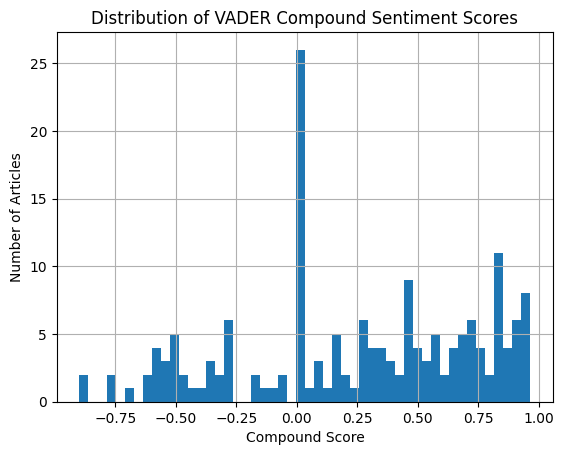

In [24]:
## Visualize the Compound Sentiment Scores

import matplotlib.pyplot as plt

df['compound_score'].hist(bins=50)
plt.title('Distribution of VADER Compound Sentiment Scores')
plt.xlabel('Compound Score')
plt.ylabel('Number of Articles')
plt.show()


In [25]:
# Define sentiment categories based on compound score thresholds
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['compound_score'].apply(label_sentiment)

In [26]:
df.head()

,title,url,summary,article_text,compound_score,sentiment_category
0,RBI policy and GST boost fuel interest in cons...,https://economictimes.indiatimes.comhttps://ec...,Consumption and financial services stocks are ...,,0.8834,Positive
1,RBI Policy Meeting 2025: Key highlights and go...,https://economictimes.indiatimes.comhttps://ec...,The RBI kept the repo rate at 5.5% with a neut...,,0.8176,Positive
2,India benchmark bonds fall on supply reshuffle...,https://economictimes.indiatimes.comhttps://ec...,Benchmark Indian government bonds fell on Mond...,,0.4767,Positive
3,India bond yields inch down on quarter-end buy...,https://economictimes.indiatimes.comhttps://ec...,Indian government bond yields eased on the qua...,,0.5106,Positive
4,If external headwinds remain and growth starts...,https://economictimes.indiatimes.comhttps://ec...,ICICI Bank predicts the Monetary Policy Commit...,,0.3612,Positive


In [27]:
##  Count how many articles in each sentiment category

sentiment_counts = df['sentiment_category'].value_counts()
print("Sentiment Category Counts:\n", sentiment_counts)


Sentiment Category Counts:
 sentiment_category
Positive    105
Negative     40
Neutral      26
Name: count, dtype: int64


In [28]:
 ##  Show examples of most positive and most negative articles

print("\nMost Positive Article:")
print(df.loc[df['compound_score'].idxmax()][['title', 'summary', 'compound_score']])

print("\nMost Negative Article:")
print(df.loc[df['compound_score'].idxmin()][['title', 'summary', 'compound_score']])


Most Positive Article:
title             Loan growth in India likely to pick up amid pu...
summary           Nomura projects India’s loan growth to rise to...
compound_score                                               0.9661
Name: 51, dtype: object

Most Negative Article:
title             RBI MPC Meeting Highlights: RBI Governor on GS...
summary           RBI MPC Highlights: The Reserve Bank of India ...
compound_score                                              -0.8979
Name: 36, dtype: object


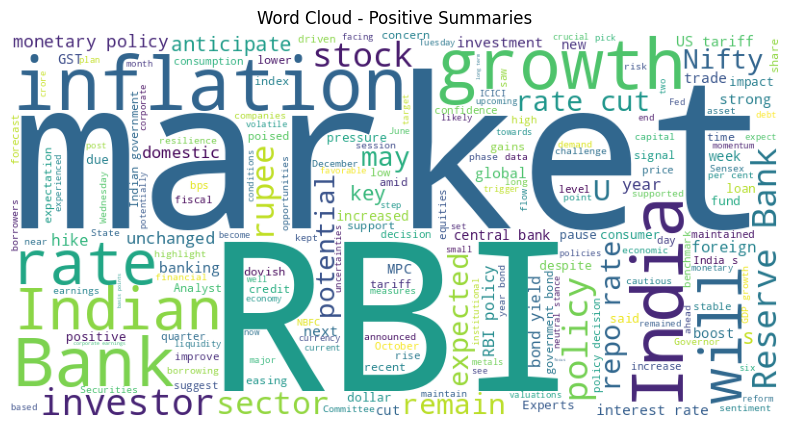

In [29]:
## Word Cloud Visualization

from wordcloud import WordCloud

positive_text = " ".join(df[df['sentiment_category']=='Positive']['summary'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud - Positive Summaries')
plt.show()



In [30]:
df.to_csv("rbi_policy_news_with_sentiments.csv", index=False)


In [31]:
from sklearn.feature_extraction.text import CountVectorizer

# Select summaries with Positive sentiment
positive_summaries = df[df['sentiment_category'] == 'Positive']['summary'].tolist()

# Vectorize text using CountVectorizer (creates document-word matrix)
cv = CountVectorizer(max_features=1000, stop_words='english')  # remove common stopwords
X = cv.fit_transform(positive_summaries)

In [32]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5  # Number of topics to extract
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)


LatentDirichletAllocation(n_components=5, random_state=42)

In [33]:
def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        topic_words = [words[i] for i in topic.argsort()[:-top_n - 1:-1]]
        print(f"Topic {i+1}: {', '.join(topic_words)}")

print_topics(lda, cv)


Topic 1: rbi, policy, bank, inflation, rate, market, indian, growth, nifty, potential
Topic 2: policy, inflation, rate, market, rbi, bank, india, growth, new, key
Topic 3: bank, indian, india, policy, rate, reserve, rupee, market, rates, bond
Topic 4: growth, policy, india, rbi, domestic, remain, investors, sector, markets, market
Topic 5: rbi, bank, rate, inflation, india, growth, policy, reserve, indian, stock
